# Exploratory Data Analysis (EDA)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("clean_data.csv")
df.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp,price_flag_suspicious,car_age,is_electric
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6,MANUAL,rear wheel drive,2,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26.0,19,3916,46135,False,6,False
1,BMW,1 Series,2011,premium unleaded (required),300.0,6,MANUAL,rear wheel drive,2,"Luxury,Performance",Compact,Convertible,28.0,19,3916,40650,False,6,False
2,BMW,1 Series,2011,premium unleaded (required),300.0,6,MANUAL,rear wheel drive,2,"Luxury,High-Performance",Compact,Coupe,28.0,20,3916,36350,False,6,False
3,BMW,1 Series,2011,premium unleaded (required),230.0,6,MANUAL,rear wheel drive,2,"Luxury,Performance",Compact,Coupe,28.0,18,3916,29450,False,6,False
4,BMW,1 Series,2011,premium unleaded (required),230.0,6,MANUAL,rear wheel drive,2,Luxury,Compact,Convertible,28.0,18,3916,34500,False,6,False


# Descriptive Statistics using Numerical Columns

In [3]:
numeric_cols = df.select_dtypes(include=np.number).columns

df[numeric_cols]

,year,engine_hp,engine_cylinders,number_of_doors,highway_mpg,city_mpg,popularity,msrp,car_age
0,2011,335.0,6,2,26.0,19,3916,46135,6
1,2011,300.0,6,2,28.0,19,3916,40650,6
2,2011,300.0,6,2,28.0,20,3916,36350,6
3,2011,230.0,6,2,28.0,18,3916,29450,6
4,2011,230.0,6,2,28.0,18,3916,34500,6
...,...,...,...,...,...,...,...,...,...
11194,2012,300.0,6,4,23.0,16,204,46120,5
11195,2012,300.0,6,4,23.0,16,204,56670,5
11196,2012,300.0,6,4,23.0,16,204,50620,5
11197,2013,300.0,6,4,23.0,16,204,50920,4


In [ ]:
# Median, Mean and Standard Deviation

keyfindings = pd.DataFrame({
    'Median': df[numeric_cols].median(),
    'Mean': df[numeric_cols].mean(),
    'Standard Deviation':df[numeric_cols].std()
})

keyfindings

,Median,Mean,Standard Deviation
year,2015.0,2010.714528,7.228211
engine_hp,239.0,253.227788,109.865570
engine_cylinders,6.0,5.661488,1.802632
number_of_doors,4.0,3.454237,0.872896
highway_mpg,25.0,26.581838,8.427817
city_mpg,18.0,19.731851,9.177555
popularity,1385.0,1558.483347,1445.668872
msrp,30675.0,41925.927136,61535.047817
car_age,2.0,6.285472,7.228211


So, what can we conclude from these statistics?

* The mean and median values show that most vehicles have around 4 doors and 6 engine cylinders.

* Engine horsepower has a relatively large spread, with a mean of 253.23 HP and a standard deviation of 109.87, indicating considerable variation between vehicles.

 * MSRP has the largest variation, with a mean of 41,925,93 compared with a median of 30,675 and a standard deviation of 61,535.05. This large difference between the mean and median suggests that some expensive vehicles are increasing the average price.

 * Popularity also has a large standard deviation, indicating substantial differences in popularity among vehicles.

 Overall, variables such as MSRP, popularity, and engine horsepower show the greatest variation.

# Analysis Of Data

### Univariate Analysis

##### Price Analysis

In [27]:
df['msrp'].describe()

count    1.119900e+04
mean     4.192593e+04
std      6.153505e+04
min      2.000000e+03
25%      2.159950e+04
50%      3.067500e+04
75%      4.303250e+04
max      2.065902e+06
Name: msrp, dtype: float64

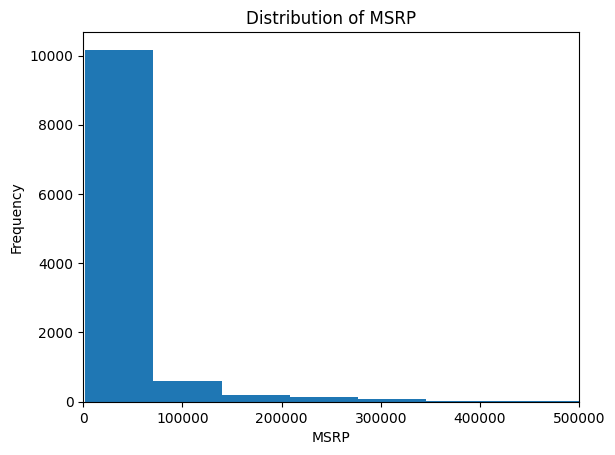

In [5]:
plt.hist(df['msrp'],bins=30)
plt.xlim(0, 500000)
plt.xlabel('MSRP')
plt.ylabel('Frequency')
plt.title('Distribution of MSRP')
plt.show()

Car prices are positively skewed, with most cars concentrated in lower price ranges and a smaller number of high-priced cars.

In [ ]:
df['msrp'].skew() # it'is right skewed >0.5

np.float64(11.609709303878942)

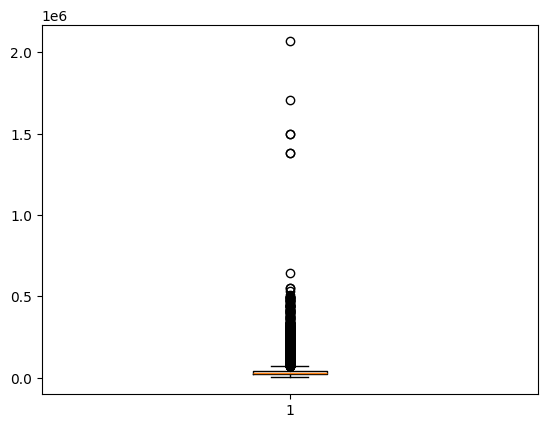

In [6]:
plt.boxplot(df['msrp'])
plt.show()

What is the most expensive car?

In [35]:
most_expensive_price=df[df['msrp']==df['msrp'].max()]
most_expensive_price

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp,price_flag_suspicious,car_age,is_electric
10661,Bugatti,Veyron 16.4,2008,premium unleaded (required),1001.0,16,AUTOMATED_MANUAL,all wheel drive,2,"Exotic,High-Performance",Compact,Coupe,14.0,8,820,2065902,False,9,False


Which brands have the highest average price?

In [36]:
highest_price_brand=df.groupby('make')['msrp'].mean().sort_values(ascending=False)
highest_price_brand.head(1)

make
Bugatti    1.757224e+06
Name: msrp, dtype: float64

#### Year Analysis

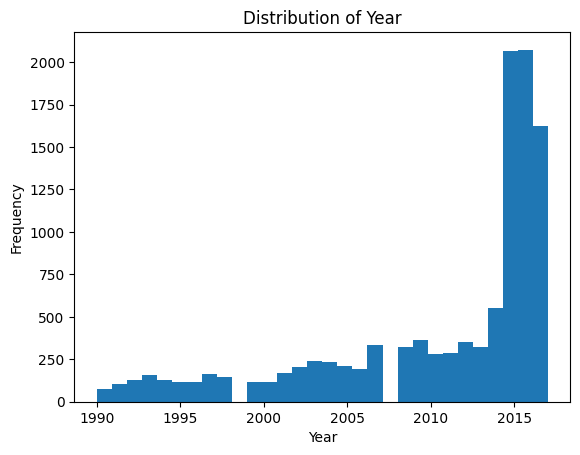

In [24]:
plt.hist(df['year'],bins=30)

plt.xlabel('Year')
plt.ylabel('Frequency')
plt.title('Distribution of Year')
plt.show()

In [ ]:
df['year'].skew() # it's negative skewness <0.5

np.float64(-1.2602258754024755)

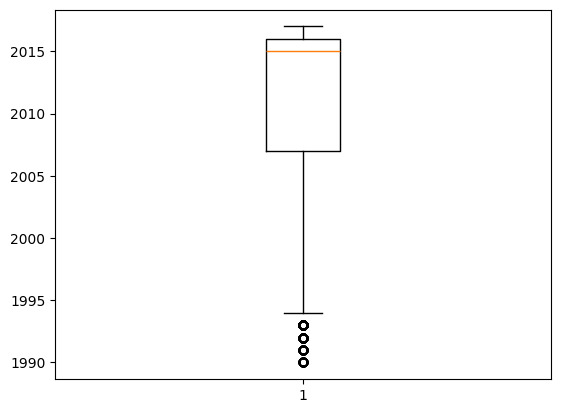

In [26]:
plt.boxplot(df['year'])
plt.show()

In which year the most number of cars is made?

In [40]:
df.groupby('year')['make'].value_counts().sort_values(ascending=False)

year  make      
2015  Chevrolet     206
2016  Chevrolet     193
      Toyota        182
2015  Toyota        167
      Volkswagen    165
                   ... 
2004  Lotus           1
2003  Lotus           1
      Volvo           1
2004  Porsche         1
2017  Lotus           1
Name: count, Length: 735, dtype: int64

#### Engine Analysis

In [29]:
df['engine_hp'].describe()

count    11199.000000
mean       253.227788
std        109.865570
min         55.000000
25%        172.000000
50%        239.000000
75%        303.000000
max       1001.000000
Name: engine_hp, dtype: float64

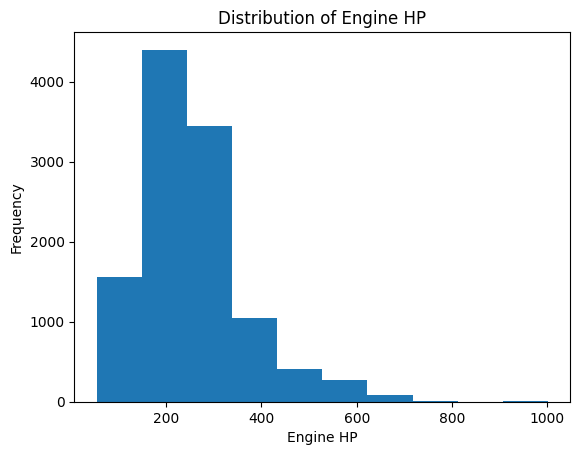

In [30]:
plt.hist(df['engine_hp'])

plt.xlabel('Engine HP')
plt.ylabel('Frequency')
plt.title('Distribution of Engine HP')
plt.show()

In [ ]:
df['engine_hp'].skew()# it's right skewed

np.float64(1.2519590571886838)

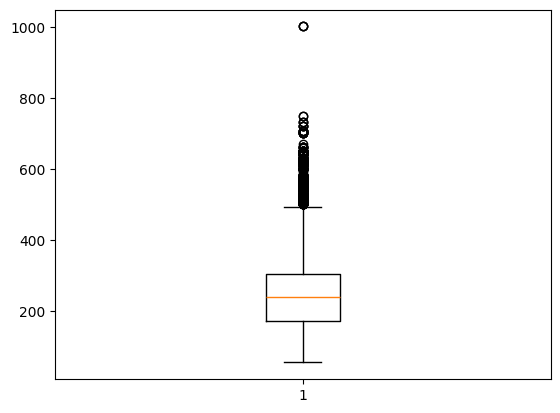

In [32]:
plt.boxplot(df['engine_hp'])
plt.show()

Who is the highest engine_hp and how many cars have this?

In [33]:
highest_engine=df[df['engine_hp']==df['engine_hp'].max()]
highest_engine['make'].value_counts()


make
Bugatti    3
Name: count, dtype: int64

Which car has highest and lowest engine hp?

In [34]:
highest_engine=df['engine_hp'].max()
lowest_engine=df['engine_hp'].min()
print(f"Highest Engine is : {highest_engine}")
print(f"Lowest Engine is : {lowest_engine}")

Highest Engine is : 1001.0
Lowest Engine is : 55.0


#### Engine Clinders Analysis

In [43]:
df['engine_cylinders'].describe()

count    11199.000000
mean         5.661488
std          1.802632
min          0.000000
25%          4.000000
50%          6.000000
75%          6.000000
max         16.000000
Name: engine_cylinders, dtype: float64

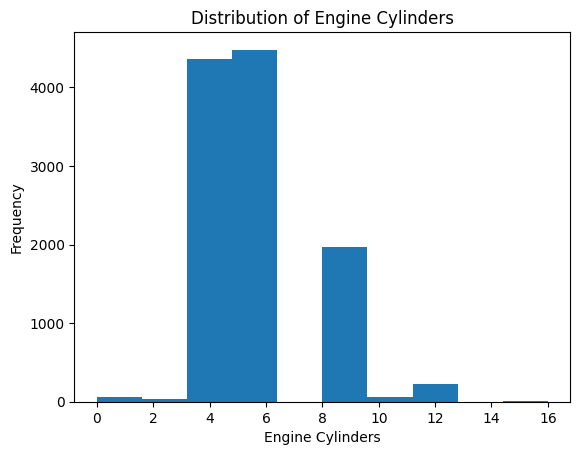

In [41]:
plt.hist(df['engine_cylinders'])
plt.xlabel('Engine Cylinders')
plt.ylabel('Frequency')
plt.title('Distribution of Engine Cylinders')
plt.show()

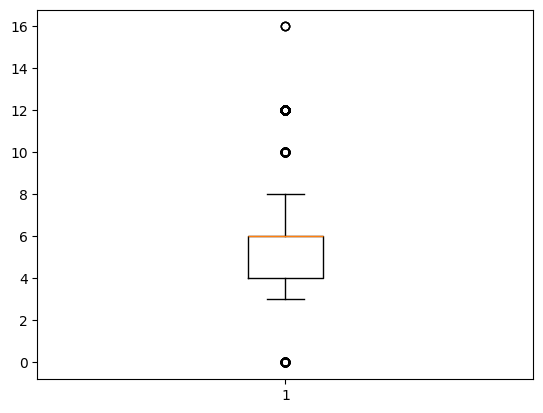

In [42]:
plt.boxplot(df['engine_cylinders'])
plt.show()

Which make has highest number of clinders?

In [46]:
df[df['engine_cylinders']==df['engine_cylinders'].max()][['make','engine_cylinders']]

,make,engine_cylinders
10661,Bugatti,16
10662,Bugatti,16
10663,Bugatti,16


#### Highway mpg Analysis

In [57]:
df['city_mpg'].describe()

count    11199.000000
mean        19.731851
std          9.177555
min          7.000000
25%         16.000000
50%         18.000000
75%         22.000000
max        137.000000
Name: city_mpg, dtype: float64

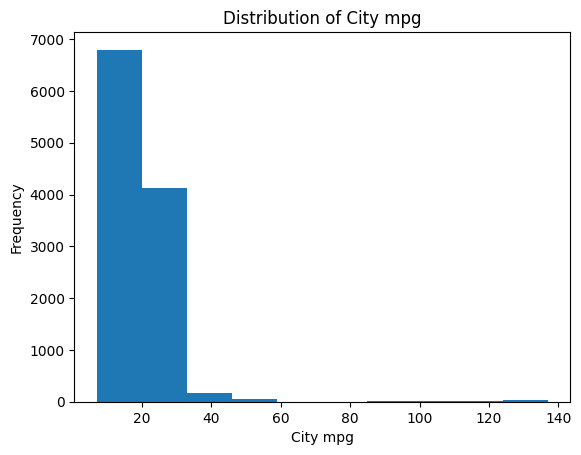

In [56]:
plt.hist(df['city_mpg'])

plt.xlabel('City mpg')
plt.ylabel('Frequency')
plt.title('Distribution of City mpg')
plt.show()

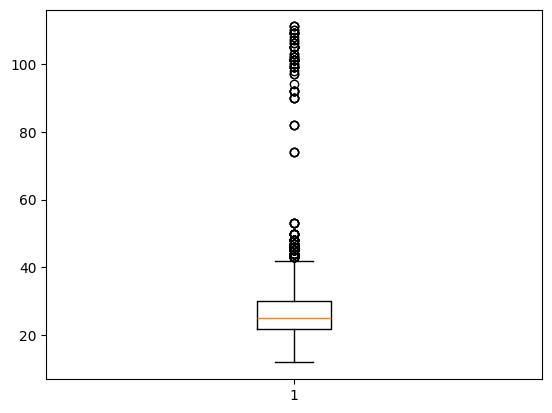

In [55]:
plt.boxplot(df['highway_mpg'])
plt.show()

who is car that has most Highway mpg?

In [58]:
df[df['city_mpg']==df['city_mpg'].max()]

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp,price_flag_suspicious,car_age,is_electric
5505,BMW,i3,2015,electric,170.0,0,DIRECT_DRIVE,rear wheel drive,4,"Hatchback,Luxury",Compact,4dr Hatchback,111.0,137,3916,42400,False,2,True
5506,BMW,i3,2016,electric,170.0,0,DIRECT_DRIVE,rear wheel drive,4,"Hatchback,Luxury",Compact,4dr Hatchback,111.0,137,3916,42400,False,1,True
5507,BMW,i3,2017,electric,170.0,0,DIRECT_DRIVE,rear wheel drive,4,"Hatchback,Luxury",Compact,4dr Hatchback,111.0,137,3916,42400,False,0,True


#### city mpg Analysis

In [51]:
df['city_mpg'].describe()

count    11199.000000
mean        19.731851
std          9.177555
min          7.000000
25%         16.000000
50%         18.000000
75%         22.000000
max        137.000000
Name: city_mpg, dtype: float64

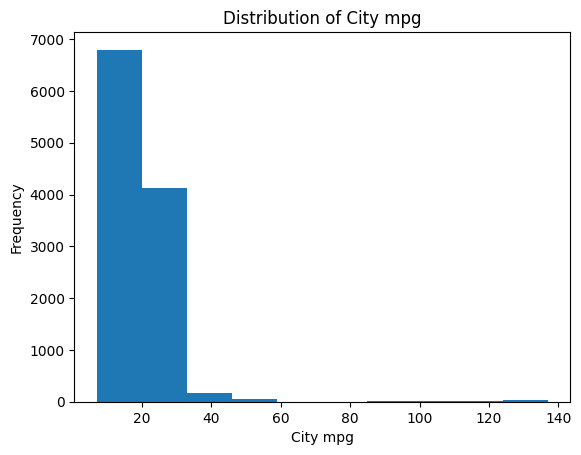

In [52]:
plt.hist(df['city_mpg'])

plt.xlabel('City mpg')
plt.ylabel('Frequency')
plt.title('Distribution of City mpg')
plt.show()

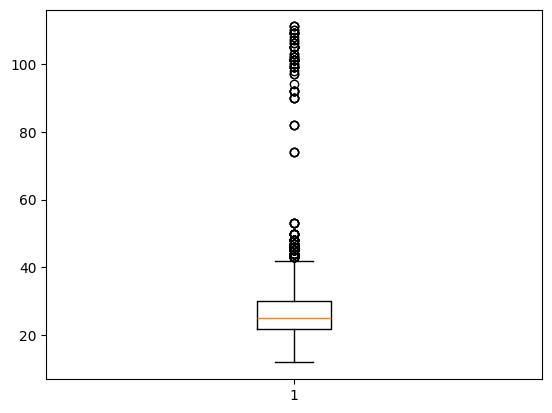

In [ ]:
plt.boxplot(df['city_mpg'])
plt.show()

who is car that has most city mpg?

In [54]:
df[df['city_mpg']==df['city_mpg'].max()]

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp,price_flag_suspicious,car_age,is_electric
5505,BMW,i3,2015,electric,170.0,0,DIRECT_DRIVE,rear wheel drive,4,"Hatchback,Luxury",Compact,4dr Hatchback,111.0,137,3916,42400,False,2,True
5506,BMW,i3,2016,electric,170.0,0,DIRECT_DRIVE,rear wheel drive,4,"Hatchback,Luxury",Compact,4dr Hatchback,111.0,137,3916,42400,False,1,True
5507,BMW,i3,2017,electric,170.0,0,DIRECT_DRIVE,rear wheel drive,4,"Hatchback,Luxury",Compact,4dr Hatchback,111.0,137,3916,42400,False,0,True


**cars** have highest highway_mpg are same of cars have highest city_mpg

#### Catogorical Analysis

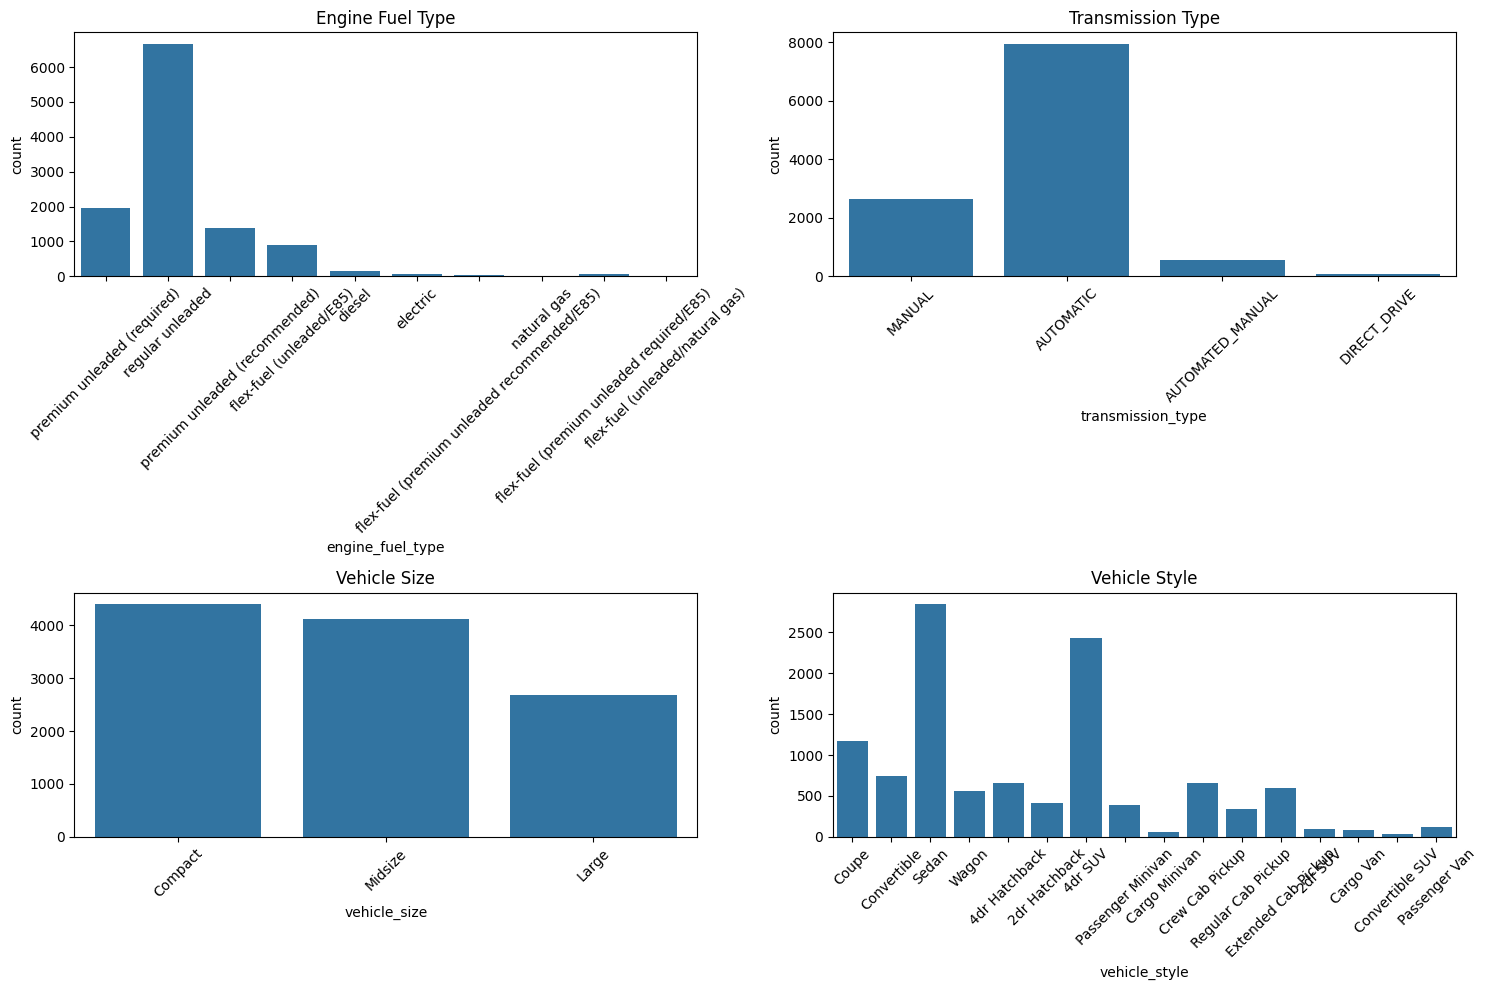

In [66]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

sns.countplot(data=df, x='engine_fuel_type', ax=axes[0, 0])
axes[0, 0].set_title('Engine Fuel Type')
axes[0, 0].tick_params(axis='x', rotation=45)

sns.countplot(data=df, x='transmission_type', ax=axes[0, 1])
axes[0, 1].set_title('Transmission Type')
axes[0, 1].tick_params(axis='x', rotation=45)

sns.countplot(data=df, x='vehicle_size', ax=axes[1, 0])
axes[1, 0].set_title('Vehicle Size')
axes[1, 0].tick_params(axis='x', rotation=45)

sns.countplot(data=df, x='vehicle_style', ax=axes[1, 1])
axes[1, 1].set_title('Vehicle Style')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


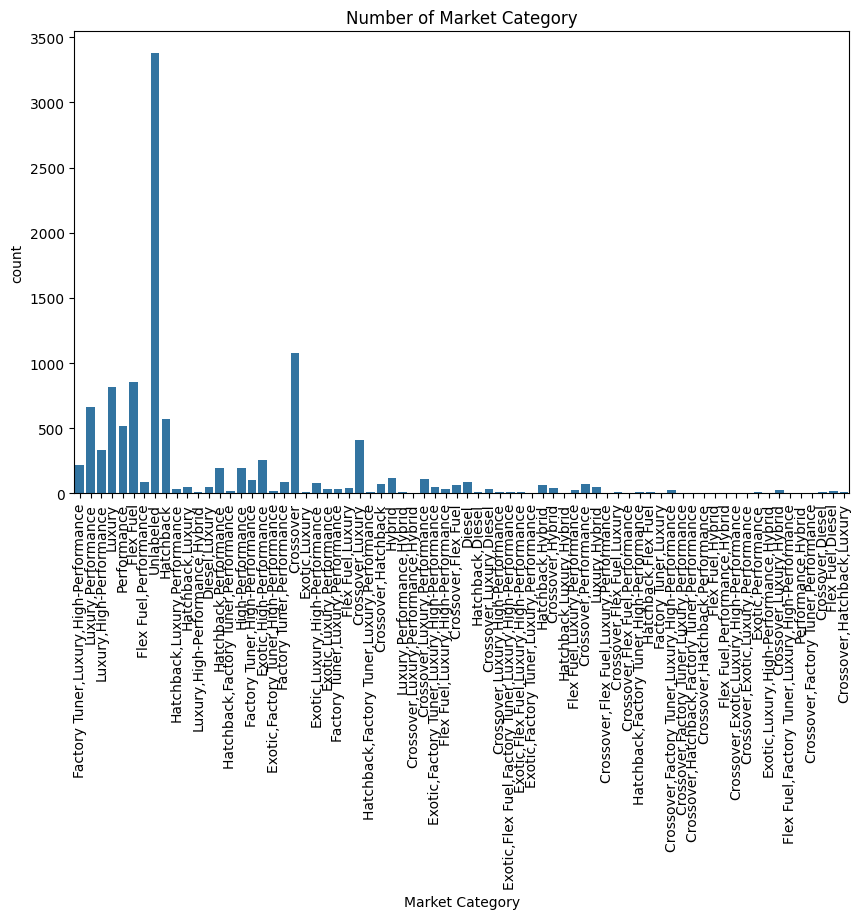

In [68]:
plt.figure(figsize=(10, 6))

sns.countplot(data=df, x='market_category')
plt.title('Number of Market Category')
plt.xlabel('Market Category')
plt.xticks(rotation=90)
plt.show()

## Hypothesis Testing

### Hypothesis 1

*Null Hypothesis* (H₀): There is no significant relationship between a car's manufacturing year and its price.

*Alternative Hypothesis* (H₁): Newer cars tend to have significantly higher prices than older cars.

In [70]:
from scipy.stats import pearsonr

# Perform Pearson correlation test
correlation, p_value = pearsonr(df['year'], df['msrp'])

print("Correlation coefficient:", correlation)
print("P-value:", p_value)

# Decision
alpha = 0.05

if p_value < alpha:
    print("Reject H₀")
    print("There is a statistically significant relationship between manufacturing year and MSRP.")
else:
    print("Fail to reject H₀")
    print("There is no statistically significant relationship between manufacturing year and MSRP.")

Correlation coefficient: 0.2096353759570143
P-value: 1.920436108627172e-111
Reject H₀
There is a statistically significant relationship between manufacturing year and MSRP.


In [11]:
mean_price=df.groupby('year')['msrp'].mean().sort_values()
mean_price


year
1990     2032.272727
1992     2108.346457
1991     2119.029126
1993     2244.693750
1994     2394.271318
1996     2566.565217
1995     2700.128205
1998     3036.151724
1999     3153.850877
1997     3164.644578
2000     3197.104348
2006    32074.850515
2002    33744.156098
2007    35278.404192
2004    36107.336170
2005    36746.971831
2003    39774.063025
2001    41500.666667
2017    42185.156308
2015    47506.329782
2016    47863.957067
2009    50404.447802
2013    51475.760000
2010    52021.117438
2008    56753.838509
2011    57570.003521
2012    61959.133903
2014    65523.254513
Name: msrp, dtype: float64

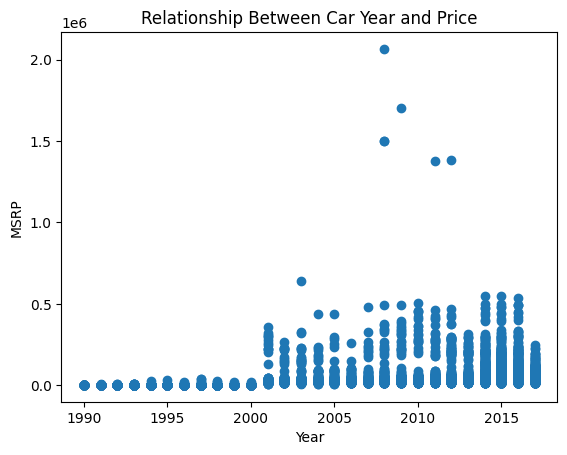

In [12]:
plt.scatter(df['year'], df['msrp'])
plt.xlabel('Year')
plt.ylabel('MSRP')
plt.title('Relationship Between Car Year and Price')
plt.show()

The data does not support the hypothesis  as there is **no clear** positive or negative relationship between year and price. As the years progress, prices can either increase or decrease.

### Hypothesis 2

Null Hypothesis (H₀):The engine type has no significant effect on car prices.

Alternative Hypothesis (H₁):The engine type has a significant effect on car prices.

In [71]:
from scipy.stats import f_oneway

# Create a list of MSRP values for each engine fuel type
groups = [
    group['msrp'].values
    for name, group in df.groupby('engine_fuel_type')
]

# Perform One-Way ANOVA
f_statistic, p_value = f_oneway(*groups)

print("F-statistic:", f_statistic)
print("P-value:", p_value)

# Decision
alpha = 0.05

if p_value < alpha:
    print("Reject H₀")
    print("Engine fuel type has a statistically significant effect on car prices.")
else:
    print("Fail to reject H₀")
    print("There is no statistically significant effect of engine fuel type on car prices.")

F-statistic: 394.4457893621208
P-value: 0.0
Reject H₀
Engine fuel type has a statistically significant effect on car prices.


In [13]:
df.groupby('engine_fuel_type')['msrp'].mean().sort_values()

engine_fuel_type
regular unleaded                                 23830.813692
natural gas                                      28065.000000
flex-fuel (unleaded/E85)                         36279.217587
flex-fuel (unleaded/natural gas)                 39194.166667
diesel                                           40449.680000
premium unleaded (recommended)                   41812.512213
electric                                         47943.030303
flex-fuel (premium unleaded recommended/E85)     48641.923077
premium unleaded (required)                     102814.088957
flex-fuel (premium unleaded required/E85)       160692.264151
Name: msrp, dtype: float64

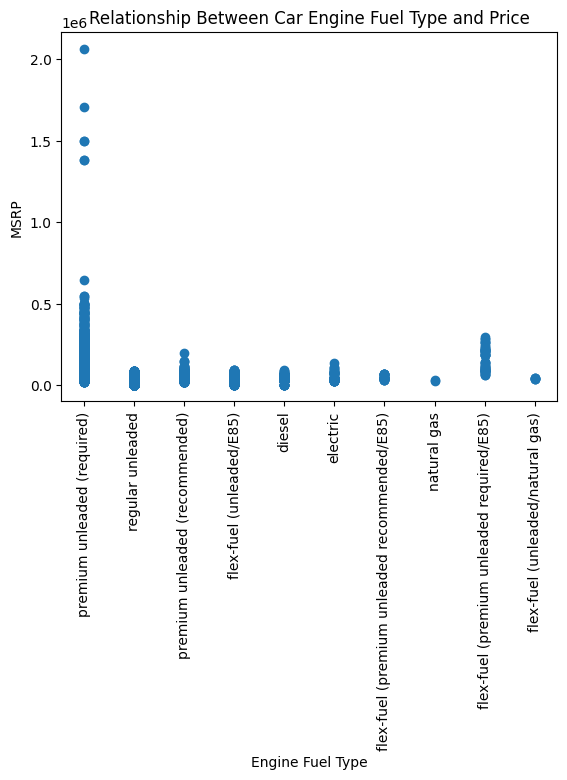

In [14]:
plt.scatter(df['engine_fuel_type'], df['msrp'])
plt.xlabel('Engine Fuel Type')
plt.xticks(rotation=90)
plt.ylabel('MSRP')
plt.title('Relationship Between Car Engine Fuel Type and Price')
plt.show()

Data doesn't support the hypothesis that tell engine fuel type may affect car prices, as the average MSRP varies considerably across different fuel types.

### Hypothesis 3

Null Hypothesis H₀: Vehicle style has no significant effect on car price.

Althernative Hypothesis H₁: Vehicle Style has a significant effect on car price.

In [72]:
# Create a group of MSRP values for each vehicle style
groups = [
    group['msrp'].values
    for name, group in df.groupby('vehicle_style')
]

# Perform One-Way ANOVA
f_statistic, p_value = f_oneway(*groups)

print("F-statistic:", f_statistic)
print("P-value:", p_value)

# Significance level
alpha = 0.05

# Decision
if p_value < alpha:
    print("Reject H₀")
    print("Vehicle style has a statistically significant relationship with car price.")
else:
    print("Fail to reject H₀")
    print("There is no statistically significant relationship between vehicle style and car price.")

F-statistic: 87.68787720674634
P-value: 5.07518781774023e-256
Reject H₀
Vehicle style has a statistically significant relationship with car price.


In [15]:
df.groupby('vehicle_style')['msrp'].mean().sort_values()

vehicle_style
2dr SUV                14306.549451
2dr Hatchback          16177.740291
Cargo Van              17019.297619
Regular Cab Pickup     17854.649275
Convertible SUV        17975.000000
Cargo Minivan          20315.593220
4dr Hatchback          22416.467572
Extended Cab Pickup    23041.772194
Wagon                  26156.939502
Passenger Minivan      26176.562982
Passenger Van          30578.066116
Crew Cab Pickup        37183.111450
Sedan                  40462.020049
4dr SUV                40730.273624
Coupe                  77595.287660
Convertible            88216.792173
Name: msrp, dtype: float64

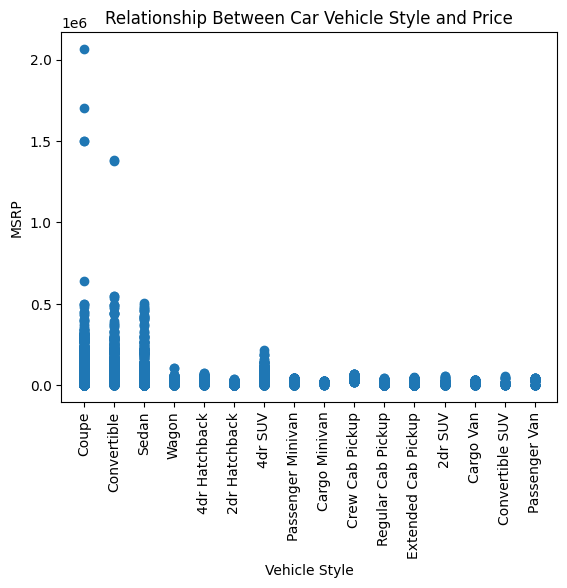

In [16]:
plt.scatter(df['vehicle_style'], df['msrp'])
plt.xlabel('Vehicle Style')
plt.xticks(rotation=90)
plt.ylabel('MSRP')
plt.title('Relationship Between Car Vehicle Style and Price')
plt.show()

The results doesn't support the hypothesis that vehicle style affects car prices because the average MSRP differs across vehicle styles.

## Correlation Analysis

In [73]:
correlation_matrix=df.corr(method='pearson',numeric_only=True)
correlation_matrix

,year,engine_hp,engine_cylinders,number_of_doors,highway_mpg,city_mpg,popularity,msrp,price_flag_suspicious,car_age,is_electric
year,1.000000,0.334954,-0.035969,0.247648,0.257986,0.188417,0.085874,0.209635,-0.631381,-1.000000,0.049041
engine_hp,0.334954,1.000000,0.774659,-0.130298,-0.390047,-0.359355,0.040224,0.658594,-0.270481,-0.334954,-0.038016
engine_cylinders,-0.035969,0.774659,1.000000,-0.151700,-0.655581,-0.592952,0.039386,0.536593,-0.098375,0.035969,-0.241829
number_of_doors,0.247648,-0.130298,-0.151700,1.000000,0.120700,0.121194,-0.057379,-0.145179,-0.126521,-0.247648,0.040123
highway_mpg,0.257986,-0.390047,-0.655581,0.120700,1.000000,0.942533,-0.021929,-0.178039,-0.036210,-0.257986,0.667032
city_mpg,0.188417,-0.359355,-0.592952,0.121194,0.942533,1.000000,-0.000549,-0.162343,-0.027142,-0.188417,0.779971
popularity,0.085874,0.040224,0.039386,-0.057379,-0.021929,-0.000549,1.000000,-0.048371,-0.041265,-0.085874,0.011450
msrp,0.209635,0.658594,0.536593,-0.145179,-0.178039,-0.162343,-0.048371,1.000000,-0.173590,-0.209635,0.007529
price_flag_suspicious,-0.631381,-0.270481,-0.098375,-0.126521,-0.036210,-0.027142,-0.041265,-0.173590,1.000000,0.631381,-0.020599
car_age,-1.000000,-0.334954,0.035969,-0.247648,-0.257986,-0.188417,-0.085874,-0.209635,0.631381,1.000000,-0.049041


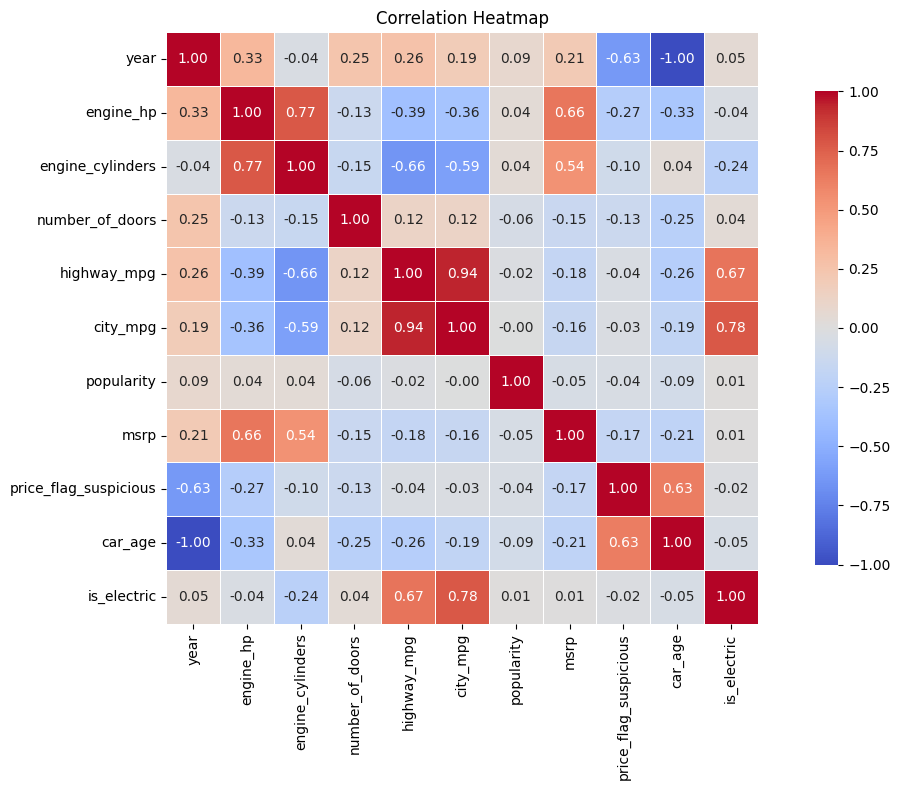

In [74]:
plt.figure(figsize=(12, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,          
    fmt='.2f',           
    cmap='coolwarm',
    center=0,              
    linewidths=0.5,
    square=True,
    cbar_kws={'shrink': 0.8}
)
plt.title('Correlation Heatmap')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Key Relationships

- There is a **strong positive relationship** between `highway_mpg` and `city_mpg`, meaning that cars with higher highway MPG tend to also have higher city MPG.

- There is a **strong positive relationship** between `city_mpg` and `is_electric`, meaning that electric cars tend to have much higher city MPG.

- There is a **strong positive relationship** between `engine_hp` and `engine_cylinders`, meaning that cars with more cylinders tend to have higher horsepower.

- There is a **positive relationship** between `highway_mpg` and `is_electric`, meaning that electric cars tend to have higher highway MPG.

- There is a **positive relationship** between `engine_hp` and `msrp`, meaning that cars with higher horsepower tend to have higher price.

- There is a **positive relationship** between `price_flag_suspicious` and `car_age`, meaning that older cars tend to be more likely flagged as having a suspicious price.

- There is a **positive relationship** between `engine_cylinders` and `msrp`, meaning that cars with more cylinders tend to have higher price.

- There is a **perfect negative relationship** between `year` and `car_age`, meaning that newer cars tend to have a lower car age (this is expected since `car_age` is directly derived from `year`).

- There is a **negative relationship** between `engine_cylinders` and `highway_mpg`, meaning that cars with more cylinders tend to have lower fuel efficiency on the highway.

- There is a **negative relationship** between `engine_cylinders` and `city_mpg`, meaning that cars with more cylinders tend to have lower fuel efficiency in the city.


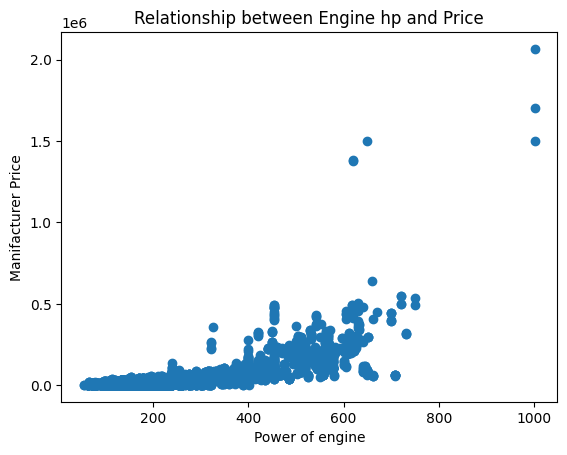

In [18]:
plt.scatter(df['engine_hp'],df['msrp'])
plt.title('Relationship between Engine hp and Price')
plt.xlabel('Power of engine')
plt.ylabel('Manifacturer Price')
plt.show()

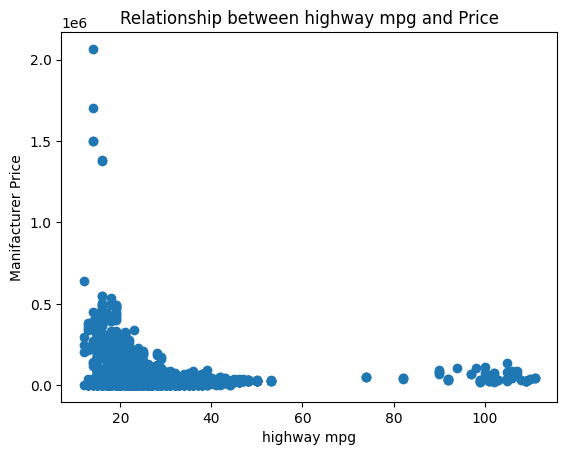

In [19]:
plt.scatter(df['highway_mpg'],df['msrp'])
plt.title('Relationship between highway mpg and Price')
plt.xlabel('highway mpg')
plt.ylabel('Manifacturer Price')
plt.show()

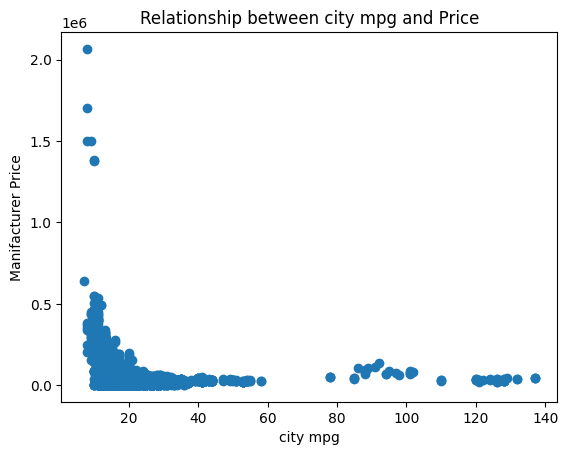

In [20]:
plt.scatter(df['city_mpg'],df['msrp'])
plt.title('Relationship between city mpg and Price')
plt.xlabel('city mpg')
plt.ylabel('Manifacturer Price')
plt.show()

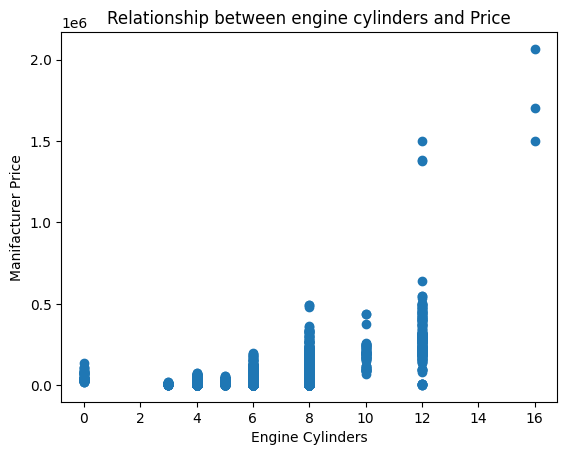

In [21]:
plt.scatter(df['engine_cylinders'],df['msrp'])
plt.title('Relationship between engine cylinders and Price')
plt.xlabel('Engine Cylinders')
plt.ylabel('Manifacturer Price')
plt.show()

# Insights & Patterns

1. Car prices are positively skewed, with most cars concentrated in lower price ranges and a smaller number of high-priced cars.
2. Newer cars generally tend to have higher prices, although the relationship is not perfectly consistent across all years.
3. Cars with higher engine hp generally tend to have higher prices.
4. Average MSRP differs across engine fuel types.
5. Vehicle style is associated with noticeable differences in average car prices.
6. Luxury and exotic market categories tend to have higher prices.
7. Cars with more cylinders generally tend to have higher prices
8. Cars with better fuel efficiency on the highway also tend to have better fuel efficiency in the city.
9. Electric cars generally have much higher city MPG
10. Electric cars tend to have higher highway MPG as well
11. Cars with more cylinders tend to have higher Engine hp